In [1]:
import os

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.nuts import nuts
from algorithms.hmc import multi_chain_hmc
from utilities.helpers import effective_sample_size, autocorr_new

# Often import when doing scientific work
jax.config.update("jax_enable_x64", True)

In [ ]:
def SIRH_model(particles,observations,t,dt,model_params,rng):
    '''Definition of the SIRHS model as used in the pf algorithm. 
    '''
    hosp,R,mu,sig = model_params #Parameters to be estimated are in the model_params vector. 

    #Fixed parameters are treated as fixed constants. 
    lam = 1/14
    L = 1/90
    D = 1/7
    gamma = 1/1000

    A = np.exp(-lam * dt)
    M = mu * (np.exp(-lam * dt) - 1)
    C = sig * np.sqrt(1 - np.exp(-2 * lam * dt))

    '''Tau leaping. The setup is flexible to whatever numerical scheme the user prefers, but the timestep dt must be fixed.
    That is, adaptive methods do not work at present.'''

    for index in range(particles.shape[0]):

        '''The loop over the particles is setup as it is to allow the model function to be jit compiled in numba. 
        Unfortunately numba can't jit compile the poisson random variable generation with a vector mean. 
        '''

        new_S = rng.poisson((L * particles[index,3,t]) * dt)
        new_I = rng.poisson((particles[index,4,t] * (particles[index,0,t] * particles[index,1,t])/np.sum(particles[index,:,t])) * dt)
        new_IH = rng.poisson((D * gamma * particles[index,1,t]) * dt)
        new_HR = rng.poisson((hosp * particles[index,2,t]) * dt)
        new_IR = rng.poisson((D *(1 - gamma) * particles[index,1,t]) * dt)

        particles[index,0,t] = np.maximum(0.,particles[index,0,t] + new_S - new_I)
        particles[index,1,t] = np.maximum(0.,particles[index,1,t] + new_I - (new_IH + new_IR))
        particles[index,2,t] = np.maximum(0.,particles[index,2,t] + new_IH - new_HR)
        particles[index,3,t] = np.maximum(0.,particles[index,3,t] + new_HR + new_IR - new_S)

        particles[index,4,t] = np.exp(A * np.log(particles[index,4,t]) - M + C * rng.standard_normal())

        observations[index,0,t] = particles[index,2,t]

    return particles,observations

def SIRH_Obs(data_point, particle_observations, model_params):
    '''The observation distribution. This returns the weights which use a log scale.'''
    r = 1/model_params[1]
    weights = nbinom_logpmf(x = data_point,p = r/(r + particle_observations[:,0] + 0.005),n = np.array([r]))
    return weights

In [ ]:
def model(x0, theta, key, t_range):
    delta_t = t_range[1] - t_range[0]
    hosp, R, log_mean, log_std = theta
    log_beta_damping = 1 / 35
    xi = 1 / 90
    d = 1 / 7
    gamma = 1 / 1000
    log_beta_mean = log_mean
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R, H, log_beta = prev_x

        N = S + I + R + H

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        new_S = rng.poisson((L * particles[index,3,t]) * dt)
        new_I = rng.poisson((particles[index,4,t] * (particles[index,0,t] * particles[index,1,t])/np.sum(particles[index,:,t])) * dt)
        new_IH = rng.poisson((D * gamma * particles[index,1,t]) * dt)
        new_HR = rng.poisson((hosp * particles[index,2,t]) * dt)
        new_IR = rng.poisson((D *(1 - gamma) * particles[index,1,t]) * dt)

        new_S = jax.random.poisson(update_keys[0],xi * R * )

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * gamma * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * xi * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R, log_beta]), next_key), jnp.array(
            [S, I, R, log_beta]
        )

    _, loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=t_range[1:],
    )

    return jnp.concatenate((x0[jnp.newaxis, :], loop_val))

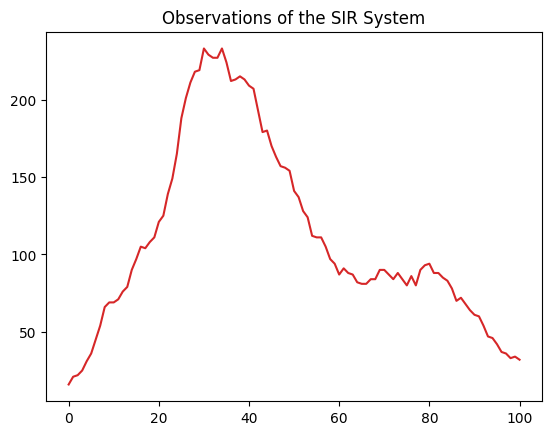

In [3]:
theta = (0.1, 1 / 90, jnp.log(0.35), 0.3)
delta_t = 1.0
days = 100
rng_key = jax.random.key(0)
t_range = jnp.arange(0, days + delta_t, delta_t)

num_models = 1_000
keys = jax.random.split(rng_key, num_models)

SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key, minval=0, maxval=20, shape=(num_models,))

x0 = jnp.full(shape=(num_models, 3), fill_value=jnp.array([1000, 0, 0]))

x0 = x0.at[:, 0].set(x0[:, 0] - I_x0)
x0 = x0.at[:, 1].set(x0[:, 1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key, shape=(num_models,), minval=0.1, maxval=0.5)

beta_x0 = beta_x0[..., jnp.newaxis]

x0 = jnp.concatenate((x0, jnp.log(beta_x0)), axis=-1)

full_state = jax.vmap(model, in_axes=(0, None, 0, None))(x0, theta, keys, t_range)

observations = full_state[0, :, 1]

plt.title("Observations of the SIR System")
plt.plot(
    t_range,
    observations.T,
    color="tab:red",
)
plt.show()

In [4]:
from algorithms.smc import particle_filter


def likelihood(particles, observation, par):
    return jax.scipy.stats.poisson.logpmf(observation, mu=particles[:, 1])


def prior(par):
    gamma, xi, log_mean, log_std = par

    gamma_prior = jax.scipy.stats.beta.logpdf(gamma, 4.0, 8.0)
    xi_prior = jax.scipy.stats.beta.logpdf(xi, 1.0, 35.0)
    log_mean_prior = jax.scipy.stats.norm.logpdf(log_mean, jnp.log(0.3), 1.0)
    log_std_prior = jax.scipy.stats.beta.logpdf(log_std, 9.0, 20.0)

    return gamma_prior + xi_prior + log_mean_prior + log_std_prior


def log_likelihood(par, observations, m, key):

    mask = jnp.arange(observations.shape[0]) < m

    N = 1000.0
    num_particles = 100
    key, init_key = jax.random.split(key)
    I_x0 = jax.random.randint(init_key, minval=0, maxval=20, shape=(num_particles,))

    particles = jnp.full(
        shape=(num_particles, 4), fill_value=jnp.array([1000.0, 0.0, 0.0, 0.0])
    )

    particles = particles.at[:, 0].set(particles[:, 0] - I_x0)
    particles = particles.at[:, 1].set(particles[:, 1] + I_x0)

    beta_init_key, key = jax.random.split(key)
    beta_x0 = jax.random.uniform(
        beta_init_key, shape=(len(particles),), minval=0.1, maxval=0.5
    )

    particles = particles.at[:, 3].set(beta_x0)

    particles, log_weights = particle_filter(
        model,
        observations,
        particles,
        key,
        likelihood,
        par,
        jnp.linspace(0, 1, 2),
    )

    log_means = jax.scipy.special.logsumexp(log_weights, axis=0) - jnp.log(
        num_particles
    )

    return jnp.sum(jnp.where(mask, log_means, 0.0)) + prior(par)

In [5]:
from algorithms.smc import ibis

num_particles = 1_000
dim = 4
scale = 0.1
p_init_key, rng_key = jax.random.split(rng_key)
gamma_key, xi_key, mean_key, std_key = jax.random.split(p_init_key,4)
particles = jnp.concatenate(
    (
        jax.random.beta(gamma_key, 4.0, 8.0, shape=(num_particles,1)),
        jax.random.beta(xi_key, 1.0, 35.0, shape=(num_particles,1)),
        jnp.log(0.3) + 0.1 * jax.random.normal(mean_key, shape=(num_particles,1)),
        jax.random.beta(std_key, 9.0, 20.0, shape=(num_particles,1)),
    ),axis = -1
)

k = 5
ibis_key, key = jax.random.split(rng_key)
particles = ibis(log_likelihood, observations, k, particles, ibis_key)

Iteration 0 with ESS 999.9999999999995
Iteration 1 with ESS 979.5404219262701
Iteration 2 with ESS 904.2880321578917
Iteration 3 with ESS 524.2947987240883
Iteration 4 with ESS 260.4553056142583
average acceptance rate: 0.216 over 5 iterations
Iteration 5 with ESS 924.3107838981105
Iteration 6 with ESS 865.6553146345075
Iteration 7 with ESS 855.3440480566378
Iteration 8 with ESS 848.4261220561119
Iteration 9 with ESS 839.0479985769487
Iteration 10 with ESS 817.98563035243
Iteration 11 with ESS 792.8318143142441
Iteration 12 with ESS 765.7429939351791
Iteration 13 with ESS 730.3244546324353
Iteration 14 with ESS 689.3202068955294
Iteration 15 with ESS 611.6202895921937
Iteration 16 with ESS 504.9919653329256
Iteration 17 with ESS 400.84809607008526
average acceptance rate: 0.23 over 5 iterations
Iteration 18 with ESS 959.5825123497692
Iteration 19 with ESS 845.7676185150005
Iteration 20 with ESS 699.003980455012
Iteration 21 with ESS 489.3492527429889
average acceptance rate: 0.2242 ove

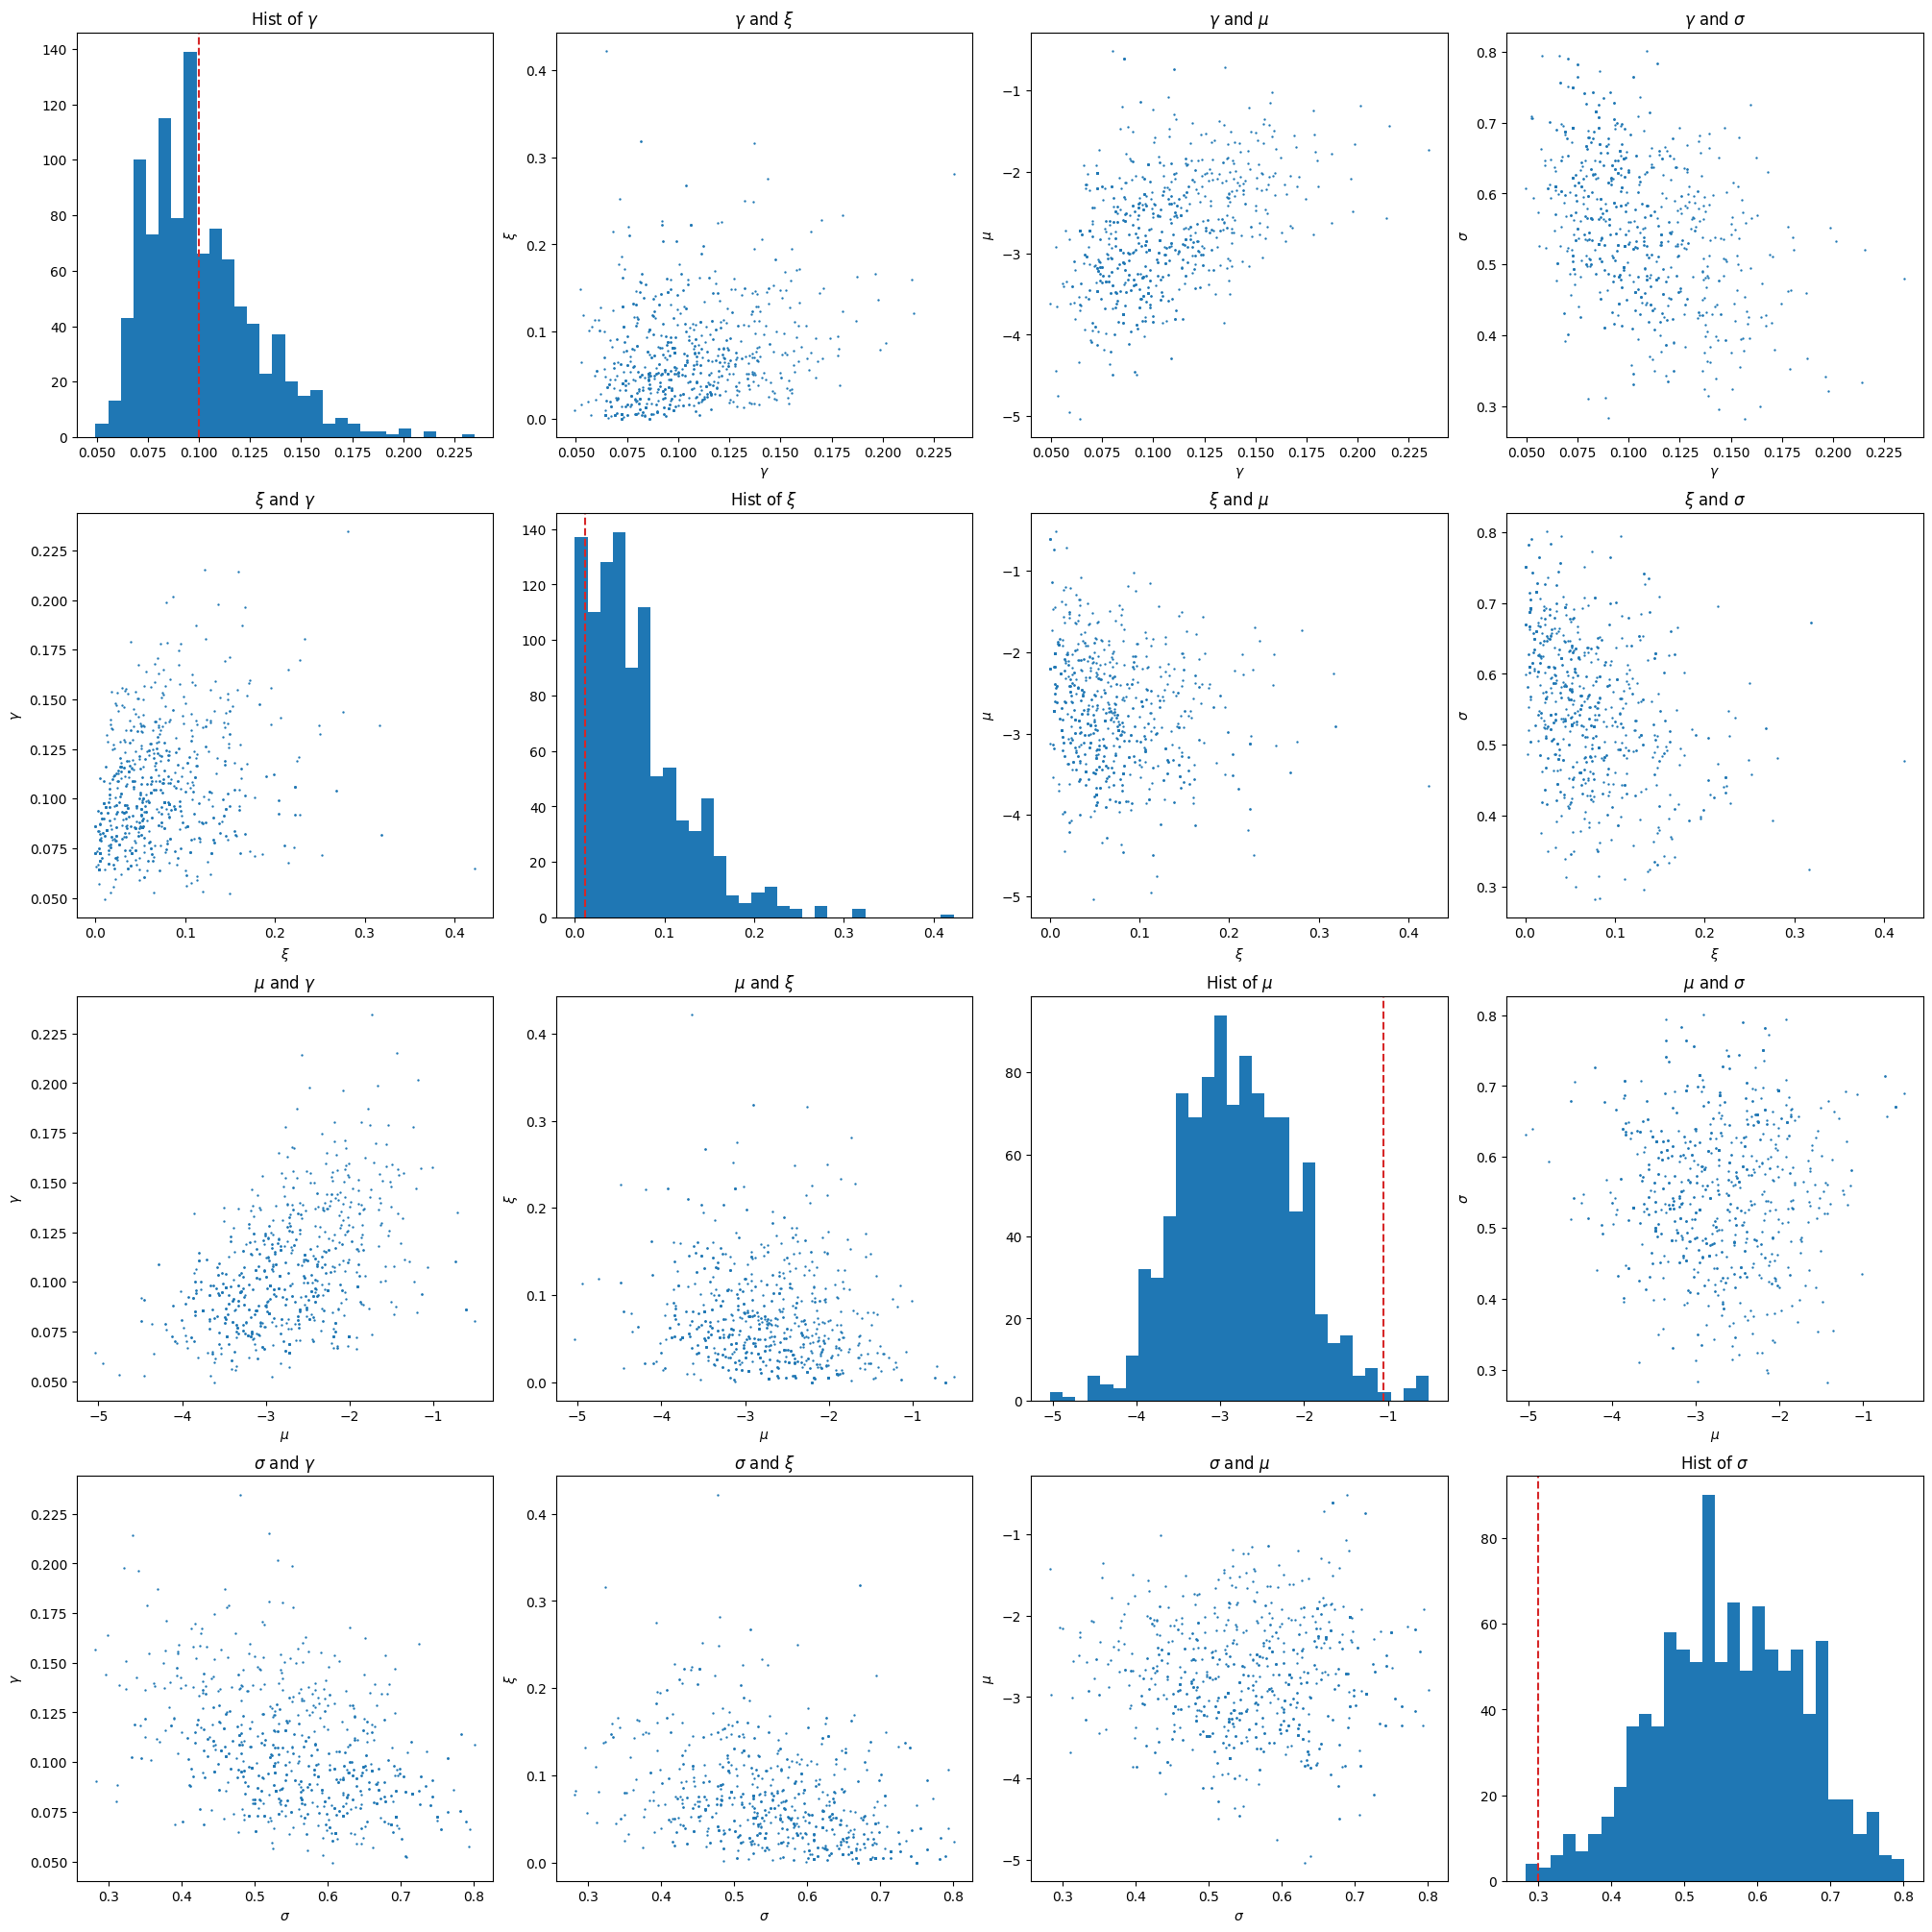

In [6]:
fig, axes = plt.subplots(dim, dim, figsize=(5 * dim, 5 * dim), layout="constrained")

par_names = ["$\\gamma$", "$\\xi$", "$\\mu$","$\\sigma$"]

for par1_index in range(dim):
    for par2_index in range(dim):
        if par1_index != par2_index:
            axes[par1_index, par2_index].set_title(
                f"{par_names[par1_index]} and {par_names[par2_index]}"
            )
            axes[par1_index, par2_index].scatter(
                particles[:, par1_index],
                particles[:, par2_index],
                s=0.5,
            )
            axes[par1_index, par2_index].set_xlabel(f"{par_names[par1_index]}")
            axes[par1_index, par2_index].set_ylabel(f"{par_names[par2_index]}")

        else:
            axes[par1_index, par2_index].hist(particles[:, par1_index], bins=30)
            axes[par1_index, par2_index].set_title(f"Hist of {par_names[par1_index]}")
            axes[par1_index, par2_index].axvline(
                theta[par1_index], color="tab:red", ls="dashed"
            )

plt.show()